In [6]:
from pathlib import Path

label_root = Path("data/makeathon-challenge/labels/train")

for x in sorted(label_root.iterdir()):
    print(f"\n{x.name}/")
    items = sorted(x.iterdir())
    for y in items[:10]:
        print("  ", y.name)
    print(f"  total: {len(items)}")


gladl/
   gladl_18NWG_6_6_alert21.tif
   gladl_18NWG_6_6_alert22.tif
   gladl_18NWG_6_6_alert23.tif
   gladl_18NWG_6_6_alert24.tif
   gladl_18NWG_6_6_alert25.tif
   gladl_18NWG_6_6_alertDate21.tif
   gladl_18NWG_6_6_alertDate22.tif
   gladl_18NWG_6_6_alertDate23.tif
   gladl_18NWG_6_6_alertDate24.tif
   gladl_18NWG_6_6_alertDate25.tif
  total: 160

glads2/
   glads2_18NWG_6_6_alert.tif
   glads2_18NWG_6_6_alertDate.tif
   glads2_18NWH_1_4_alert.tif
   glads2_18NWH_1_4_alertDate.tif
   glads2_18NWJ_8_9_alert.tif
   glads2_18NWJ_8_9_alertDate.tif
   glads2_18NWM_9_4_alert.tif
   glads2_18NWM_9_4_alertDate.tif
   glads2_18NXH_6_8_alert.tif
   glads2_18NXH_6_8_alertDate.tif
  total: 16

radd/
   radd_18NWG_6_6_labels.tif
   radd_18NWH_1_4_labels.tif
   radd_18NWJ_8_9_labels.tif
   radd_18NWM_9_4_labels.tif
   radd_18NXH_6_8_labels.tif
   radd_18NXJ_7_6_labels.tif
   radd_18NYH_9_9_labels.tif
   radd_19NBD_4_4_labels.tif
   radd_47QMB_0_8_labels.tif
   radd_47QQV_2_4_labels.tif
  total: 16

In [7]:
from pathlib import Path
import rasterio

tile_id = "18NWG_6_6"
year = 2020

s2_path = Path(f"data/makeathon-challenge/sentinel-2/train/{tile_id}__s2_l2a/{tile_id}__s2_l2a_{year}_1.tif")
aef_path = Path(f"data/makeathon-challenge/aef-embeddings/train/{tile_id}_{year}.tiff")

for name, path in [("S2", s2_path), ("AEF", aef_path)]:
    print(f"\n{name}: {path}")
    with rasterio.open(path) as src:
        print("  CRS      :", src.crs)
        print("  Shape    :", src.shape)
        print("  Count    :", src.count)
        print("  DType    :", src.dtypes[0])
        print("  Nodata   :", src.nodata)
        print("  Bounds   :", src.bounds)
        print("  Transform:", src.transform)


S2: data/makeathon-challenge/sentinel-2/train/18NWG_6_6__s2_l2a/18NWG_6_6__s2_l2a_2020_1.tif
  CRS      : EPSG:32618
  Shape    : (1002, 1002)
  Count    : 12
  DType    : uint16
  Nodata   : 0.0
  Bounds   : BoundingBox(left=559990.0, bottom=129990.0, right=570010.0, top=140010.0)
  Transform: | 10.00, 0.00, 559990.00|
| 0.00,-10.00, 140010.00|
| 0.00, 0.00, 1.00|

AEF: data/makeathon-challenge/aef-embeddings/train/18NWG_6_6_2020.tiff
  CRS      : EPSG:4326
  Shape    : (1004, 998)
  Count    : 64
  DType    : float32
  Nodata   : nan
  Bounds   : BoundingBox(left=-74.46069031996974, bottom=1.1760285484635542, right=-74.37069455340898, top=1.2665653717371024)
  Transform: | 0.00, 0.00,-74.46|
| 0.00,-0.00, 1.27|
| 0.00, 0.00, 1.00|


In [8]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

tile_id = "18NWG_6_6"
year = 2020

s2_path = Path(f"data/makeathon-challenge/sentinel-2/train/{tile_id}__s2_l2a/{tile_id}__s2_l2a_{year}_1.tif")
aef_path = Path(f"data/makeathon-challenge/aef-embeddings/train/{tile_id}_{year}.tiff")

out_dir = Path("cache/aligned_aef")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"{tile_id}_{year}_aef_on_s2_grid.tif"

with rasterio.open(s2_path) as s2_src:
    dst_crs = s2_src.crs
    dst_transform = s2_src.transform
    dst_height = s2_src.height
    dst_width = s2_src.width
    dst_profile = s2_src.profile.copy()

with rasterio.open(aef_path) as aef_src:
    print("AEF CRS:", aef_src.crs)
    print("AEF shape:", aef_src.shape)
    print("AEF bands:", aef_src.count)
    print("AEF dtype:", aef_src.dtypes[0])
    print("AEF nodata:", aef_src.nodata)

    dst_data = np.full(
        (aef_src.count, dst_height, dst_width),
        np.nan,
        dtype=np.float32
    )

    for b in range(1, aef_src.count + 1):
        reproject(
            source=rasterio.band(aef_src, b),
            destination=dst_data[b - 1],
            src_transform=aef_src.transform,
            src_crs=aef_src.crs,
            src_nodata=np.nan,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear,
        )

profile = dst_profile.copy()
profile.update(
    driver="GTiff",
    height=dst_height,
    width=dst_width,
    count=dst_data.shape[0],
    dtype="float32",
    nodata=np.nan,
    compress="lzw"
)

with rasterio.open(out_path, "w", **profile) as dst:
    dst.write(dst_data)

print("Saved to:", out_path)

AEF CRS: EPSG:4326
AEF shape: (1004, 998)
AEF bands: 64
AEF dtype: float32
AEF nodata: nan
Saved to: cache/aligned_aef/18NWG_6_6_2020_aef_on_s2_grid.tif


In [9]:
import rasterio
import numpy as np

with rasterio.open(out_path) as src:
    arr = src.read()
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Count:", src.count)
    print("Dtype:", arr.dtype)
    print("NaN fraction:", np.isnan(arr).mean())

CRS: EPSG:32618
Shape: (1002, 1002)
Count: 64
Dtype: float32
NaN fraction: 0.003988031920191553


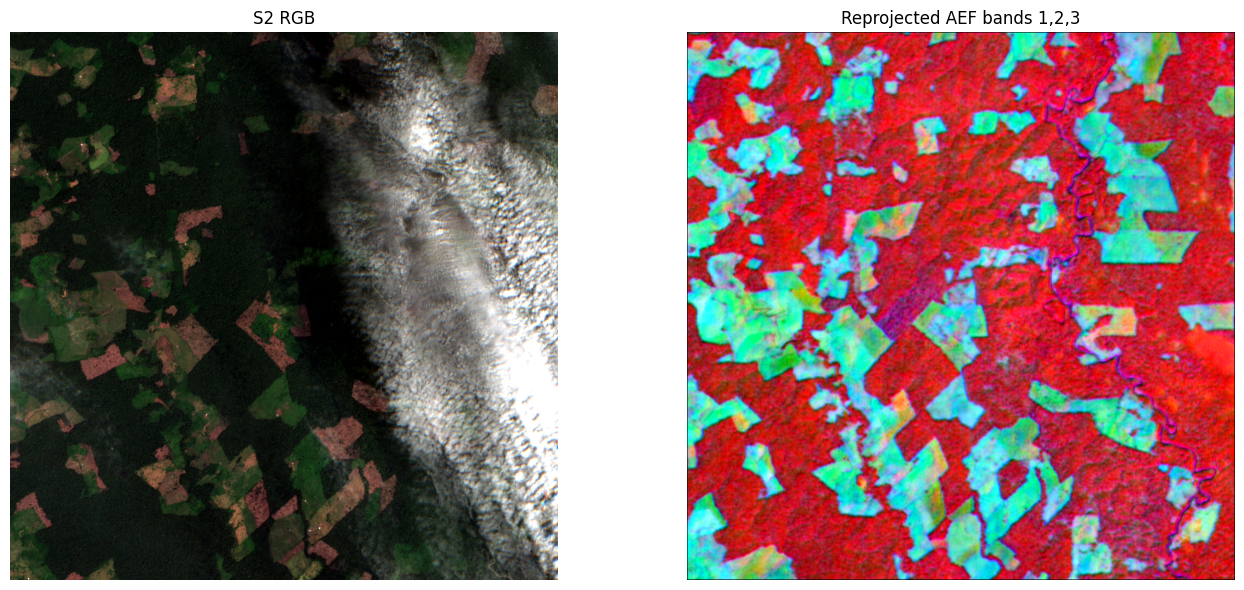

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio

def norm_band(x):
    valid = x[np.isfinite(x)]
    if len(valid) == 0:
        return np.zeros_like(x, dtype=np.float32)
    lo, hi = np.percentile(valid, [2, 98])
    return np.nan_to_num(np.clip((x - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

with rasterio.open(s2_path) as s2_src:
    red = s2_src.read(4).astype(np.float32)
    green = s2_src.read(3).astype(np.float32)
    blue = s2_src.read(2).astype(np.float32)
    s2_rgb = np.stack([norm_band(red), norm_band(green), norm_band(blue)], axis=-1)

with rasterio.open(out_path) as aef_src:
    aef = aef_src.read([1, 2, 3]).astype(np.float32)
    aef_rgb = np.stack([norm_band(aef[i]) for i in range(3)], axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(s2_rgb)
axes[0].set_title("S2 RGB")
axes[0].axis("off")

axes[1].imshow(aef_rgb)
axes[1].set_title("Reprojected AEF bands 1,2,3")
axes[1].axis("off")

plt.tight_layout()
plt.show()